#### 1. Сбор и подготовка данных 

*   Исторические данные о продажах, остатках и поступлениях. 

*   Пример  SQL-запроса для выгрузки агрегатных данных

In [ ]:
# Настройка путей и импортов
import sys
from pathlib import Path

# Найдём корень проекта (где лежит README.md или config.py)
def find_project_root(marker="config.py"):
    current = Path().resolve()
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise RuntimeError(f"Project root with '{marker}' not found!")

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

# Добавим корень проекта в sys.path, чтобы импортировать src и config
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Путь к данным
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "report.csv"
assert CSV_PATH.exists(), f"CSV file not found at {CSV_PATH}"
print(f"CSV file: {CSV_PATH}")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from config import RAW_DATA_DIR
from src.db.queries import run_query


In [3]:
# Автоматически перезагружает модули при изменении кода в .py-файлах.
# Не нужно перезапускать ядро после каждого изменения в src/.

# %load_ext autoreload
# %autoreload 2

In [3]:
df = pd.read_csv(
    CSV_PATH,                      # путь к файлу
    sep=';',                       # разделитель - точка с запятой
    parse_dates=['sale_date'],     # колонка для преобразования в дату
    encoding='utf-8',              # кодировка файла
    dtype={'product_id': 'int64'}  # тип данных для колонки product_id
                                   #  nrows=100 (прочитать только первые 100 строк)
)

In [5]:
# Сортируем от новых к старым
df_sorted = df.sort_values('sale_date', ascending=False)

# Проверяем результат
display(df_sorted.head(10))

,product_id,category,model_name,sale_date,quantity,revenue,stock_on_hand
49083,5,Clothing,Model_5,2026-03-07,3,97.50,47
49048,19,Clothing,Model_19,2026-03-06,4,438.24,80
49032,3,Clothing,Model_3,2026-03-06,5,533.70,110
49033,9,Clothing,Model_9,2026-03-06,2,66.80,103
49034,8,Electronics,Model_8,2026-03-06,3,106.35,64
49035,7,Clothing,Model_7,2026-03-06,5,302.25,109
49036,13,Clothing,Model_13,2026-03-06,4,216.56,25
49037,13,Clothing,Model_13,2026-03-06,5,270.70,25
49038,12,Electronics,Model_12,2026-03-06,5,287.30,83
49039,4,Electronics,Model_4,2026-03-06,6,213.54,50


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49084 entries, 0 to 49083
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   product_id     49084 non-null  int64         
 1   category       49084 non-null  object        
 2   model_name     49084 non-null  object        
 3   sale_date      49084 non-null  datetime64[ns]
 4   quantity       49084 non-null  int64         
 5   revenue        49084 non-null  float64       
 6   stock_on_hand  49084 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 2.6+ MB


In [7]:
print(f"Данные: {len(df)} строк, {df.columns.tolist()}")

Данные: 49084 строк, ['product_id', 'category', 'model_name', 'sale_date', 'quantity', 'revenue', 'stock_on_hand']


In [8]:
# Вариант Б: Запрос к БД 
# from src.db.queries import run_query ⬆
# QUERY = "SELECT ... -- запрос"
# df = run_query(QUERY) 

query = '''
SELECT 
    p.product_id,
    p.category,
    p.model_name,
    p.cost_price,
    p.sale_price,
    s.sale_id,
    s.sale_date::DATE AS sale_date,          -- Приводим к дате для удобства
    s.sale_date::TIME AS sale_time,          -- Выделяем время отдельно
    s.quantity,
    (s.quantity * p.sale_price) AS revenue,  -- Выручка по строке
    s.customer_id,
    inv.stock_on_hand,
    inv.operation_type
FROM sales s
JOIN products p ON s.product_id = p.product_id
LEFT JOIN inventory_log inv 
    ON s.product_id = inv.product_id 
    AND s.sale_date::DATE = inv.date
ORDER BY s.sale_date;
'''
df_2 = run_query(query)

# Преобразуем дату в datetime
df_2['sale_date'] = pd.to_datetime(df_2['sale_date'])

# Сортируем от новых к старым
df_sorted = df_2.sort_values('sale_date', ascending=False)

# Проверяем результат
display(df_sorted.head(10))

2026-03-13 11:26:02.235 | INFO     | src.db.queries:run_query:28 - Query returned 49084 rows


,product_id,category,model_name,cost_price,sale_price,sale_id,sale_date,sale_time,quantity,revenue,customer_id,stock_on_hand,operation_type
49083,5,Clothing,Model_5,23.92,32.50,49084,2026-03-07,00:00:00,3,97.50,950,47,snapshot
49048,19,Clothing,Model_19,11.09,109.56,49049,2026-03-06,13:15:00,4,438.24,317,80,snapshot
49032,3,Clothing,Model_3,20.09,106.74,49033,2026-03-06,06:15:00,5,533.70,24,110,snapshot
49033,9,Clothing,Model_9,31.98,33.40,49034,2026-03-06,06:30:00,2,66.80,364,103,snapshot
49034,8,Electronics,Model_8,51.93,35.45,49035,2026-03-06,07:15:00,3,106.35,224,64,snapshot
49035,7,Clothing,Model_7,42.21,60.45,49036,2026-03-06,07:30:00,5,302.25,140,109,snapshot
49036,13,Clothing,Model_13,47.09,54.14,49037,2026-03-06,07:45:00,4,216.56,926,25,snapshot
49037,13,Clothing,Model_13,47.09,54.14,49038,2026-03-06,08:30:00,5,270.70,896,25,snapshot
49038,12,Electronics,Model_12,45.72,57.46,49039,2026-03-06,10:30:00,5,287.30,735,83,snapshot
49039,4,Electronics,Model_4,18.08,35.59,49040,2026-03-06,10:45:00,6,213.54,419,50,snapshot


In [ ]:
df_2.info()

In [ ]:
# ЭКСПОРТ РЕЗУЛЬТАТОВ

# Сохранить очищенные данные
EXPORT_PATH = PROJECT_ROOT / "data" / "exports" / "00002_analysis_ready.csv"
EXPORT_PATH.parent.mkdir(exist_ok=True)
df.to_csv(EXPORT_PATH, index=False)
print(f"Экспорт: {EXPORT_PATH}")

In [10]:
print(f"Всего строк: {len(df):,}")
print(f"Период: {df['sale_date'].min().date()} - {df['sale_date'].max().date()}")
print(f"Категории: {df['category'].unique().tolist()}")
print(f"Товаров: {df['product_id'].nunique()}")


Всего строк: 49,084
Период: 2024-03-07 - 2026-03-07
Категории: ['Electronics', 'Clothing']
Товаров: 20


In [11]:
# Фильтруем один товар и считаем продажи по дням
product_3 = df[df['product_id'] == 3].copy()
daily = product_3.groupby('sale_date')['quantity'].sum().reset_index()
daily.columns = ['sale_date', 'daily_sales']

display(daily.head(10))

,sale_date,daily_sales
0,2024-03-07,6
1,2024-03-08,8
2,2024-03-09,27
3,2024-03-10,26
4,2024-03-11,2
5,2024-03-12,16
6,2024-03-13,22
7,2024-03-14,18
8,2024-03-15,5
9,2024-03-16,8


#### Шаг 2: Сравниваем min_periods в расчёте волатильности

In [12]:
# БЕЗ min_periods (первые 29 дней = NaN)
daily['std_no_min'] = daily['daily_sales'].rolling(window=30).std()

# С min_periods=7 (начинаем считать с 7-го дня)
daily['std_with_min'] = daily['daily_sales'].rolling(window=30, min_periods=7).std()

# Показываем первые 15 строк
display(daily[['sale_date', 'daily_sales', 'std_no_min', 'std_with_min']].head(15))

,sale_date,daily_sales,std_no_min,std_with_min
0,2024-03-07,6,NaN,NaN
1,2024-03-08,8,NaN,NaN
2,2024-03-09,27,NaN,NaN
3,2024-03-10,26,NaN,NaN
4,2024-03-11,2,NaN,NaN
5,2024-03-12,16,NaN,NaN
6,2024-03-13,22,NaN,10.111286
7,2024-03-14,18,NaN,9.410291
8,2024-03-15,5,NaN,9.488297
9,2024-03-16,8,NaN,9.174845


#####  `groupby().sum()` vs `transform('sum')` 

In [13]:
# Задача: добавить каждому чеку общую сумму продаж этого товара за весь период
# 
# Используй sum() (агрегацию): теряем строки
total_by_product = df.groupby('product_id')['quantity'].sum()
print(total_by_product.head())

# Используй transform('sum'): сохраняем структуру, добавляем колонку
df['total_sales_qty'] = df.groupby('product_id')['quantity'].transform('sum')

# В каждой строке теперь есть общая сумма по товару
display(df[df['product_id'] == 3][['product_id', 'quantity', 'total_sales_qty']].head()) 

product_id
1    4583
2    9013
3    8892
4    8940
5    8698
Name: quantity, dtype: int64


,product_id,quantity,total_sales_qty
5,3,6,8892
78,3,2,8892
114,3,6,8892
128,3,4,8892
131,3,4,8892


##### Другие примеры `transform`

```text
# Среднее по категории
df['avg_price_category'] = df.groupby('category')['price'].transform('mean')

# Максимум по товару
df['max_sale'] = df.groupby('product_id')['quantity'].transform('max')

# Количество транзакций товара
df['num_transactions'] = df.groupby('product_id')['transaction_id'].transform('count')
```

#### Визуализация "Коридора запаса" для `Model_3`

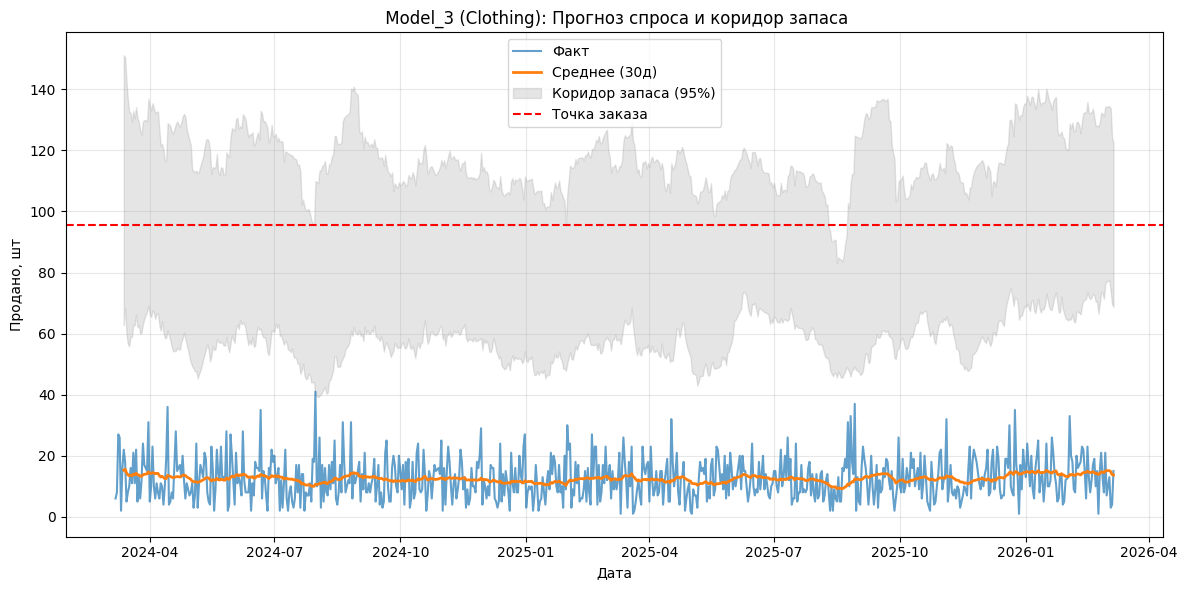

In [14]:
# Считаем метрики для одного товара

prod_df = daily.sort_values('sale_date').copy()
lead_time = 7
z_score = 1.65  # 95% сервис

# Скользящее среднее и отклонение
prod_df['rolling_avg'] = prod_df['daily_sales'].rolling(30, min_periods=7).mean()
prod_df['rolling_std'] = prod_df['daily_sales'].rolling(30, min_periods=7).std()

# Точка заказа и страховой запас
prod_df['reorder_point'] = prod_df['rolling_avg'] * lead_time
prod_df['safety_stock'] = z_score * prod_df['rolling_std'] * np.sqrt(lead_time)

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(prod_df['sale_date'], prod_df['daily_sales'], label='Факт', alpha=0.7)
plt.plot(prod_df['sale_date'], prod_df['rolling_avg'], label='Среднее (30д)', linewidth=2)

# Коридор: верхняя и нижняя границы
plt.fill_between(prod_df['sale_date'],
                prod_df['reorder_point'] - prod_df['safety_stock'],
                prod_df['reorder_point'] + prod_df['safety_stock'],
                alpha=0.2, color='gray', label='Коридор запаса (95%)')

plt.axhline(y=prod_df['reorder_point'].iloc[-1], color='red', linestyle='--', label='Точка заказа')
plt.title(' Model_3 (Clothing): Прогноз спроса и коридор запаса')
plt.xlabel('Дата'); plt.ylabel('Продано, шт')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

```text
Количество
   ↑
80 |                    
70 |━━━━━━━━━━━━━━ ← ВЕРХНЯЯ ГРАНИЦА (reorder_point + safety_stock)
   |    ░░░░░░░░░░    
60 |    ░░░░░░░░░░    
50 |━━━━░░░░░░░░░░━ ← ТОЧКА ЗАКАЗА (reorder_point)
   |    ░░░░░░░░░░    
40 |    ░░░░░░░░░░    
30 |━━━━━━━━━━━━━━ ← НИЖНЯЯ ГРАНИЦА (reorder_point - safety_stock)
   |
   +────────────────────────→ Время
   
   ```

**`reorder_point`** = `средний спрос × время доставки`

**`safety_stock`** = `Z × σ × √(lead_time)`

где:
  **Z** = 1.65 (для 95% уровня сервиса)
  
  **σ** = стандартное отклонение спроса (волатильность). **Насколько сильно "скачет" спрос** - мера неопределенности

  **`lead_time`** = **сколько дней едет товар от поставщика**. Неопределенность растет не линейно, а как корень из времени (свойство дисперсии)

**`Upper Bound`** = `Reorder Point + Safety Stock`

  **Уровень сервиса 95%** = "Мы хотим, чтобы в 95 случаях из 100 у нас ХВАТИЛО товара на складе, чтобы удовлетворить спрос".
  
**Кофе в зернах. Спрос каждый день:**
```text
День 1: 10 упаковок
День 2: 15 упаковок  
День 3: 8 упаковок
День 4: 22 упаковки ← всплеск!
День 5: 12 упаковок
...
```
Если вы бедете держать на складе **только средний спрос** (например, 13 упаковок), то в дни всплесков (22 упаковки) вы **останетесь без товара ->**  потеряете продажи и клиентов.

Мы добавляем **страховой запас** (safety stock), рассчитанный так, чтобы покрыть **непредвиденные всплески** в 95% случаев.


|Уровень сервиса |Z-score |Что означает                  
|:---------------|:-------|:-----------------------------------------|
|90%             |1.28    |Хватит запаса в 90 днях из 100            |
|95%             |1.65    |Хватит в 95 днях из 100 ← наш выбор       |
|99%             |2.33    |Хватит в 99 днях из 100 (но запас дороже!)|

**Мы допускаем дефицит (out-of-stock) только в 5% случаев.**

**Пример:**

* Средний спрос: 13 шт/день
* Волатильность (𝝈): 4 шт
* Время доставки: 7 дней

**Safety Stock** = `1.65 × 4 × √7 ≈ 1.65 × 4 × 2.65 ≈ 17.5 шт`

**-->** Значит, кроме "среднего запаса на время доставки" (13 * 7 = 91 шт), нужно держать **еще  ~18 шт про запас**.





##### Пример в цифрах (кофе):
```text
Дано:
• Средний спрос (μ) = 18 шт/день
• Волатильность (σ) = 3.72 шт
• Время доставки = 7 дней

Расчёт для 95% сервиса:
• Точка заказа = 18 × 7 = 126 шт
• Страховой запас = 1.65 × 3.72 × √7 ≈ 16 шт
• Верхняя граница = 126 + 16 = 142 шт

Что это значит:
✅ Если спрос ≤ 142 шт за неделю доставки — товара хватит (95% вероятность)
❌ Если спрос > 142 шт — возможен дефицит (5% вероятность)
```


#### 🔄 Как выбрать уровень сервиса?

Задайте три вопроса:

1. **Насколько критичен дефицит?**

    * Клиент уйдет к конкуренту? --> выше сервис
    * Клиент подождет/купит аналог? --> можно ниже
    
2. **Какова маржинальность товара?**

    * Высокая маржа --> можно держать больше запаса
    * Низкая маржа --> экономия на запасе

3. **Как быстро товар устаревает?**

    * Свежая выпечка --> низкий сервис (лучше недопроизвести)
    * Электроника --> высокий сервис (долгосрочный спрос)

```text
# Рекомендации по категориям
SERVICE_LEVELS = {
    'Хиты продаж': 0.99,      # Всегда в наличии
    'Основной ассортимент': 0.95,  # Баланс (наш пример)
    'Сезонные товары': 0.90,  # Можно рискнуть
    'Уценённые/остатки': 0.80  # Минимум вложений
}
```

**Откуда 1.65?** Это квантиль нормального распределения: `scipy.stats.norm.ppf(0.95) ≈ 1.645`. Если хотим 99% - берём `z_score = 2.33`

##### Почему именно 1.65 для 95%?

В нормальном распределении:

*   `±1σ покрывает ~68% случаев `
*   `±1.65σ покрывает ~95% случаев`
*   `±2σ покрывает ~97.5% случаев`


```text
Распределение спроса:
                    
        ▂▃▅▇█▇▅▃▂
      ▂▃▅▇█████▇▅▃▂
    ▂▃▅▇█████████▇▅▃▂
   ▂▃▅▇███████████▇▅▃▂
  ▂▃▅▇█████████████▇▅▃▂
 ─┼────┼────┼────┼────┼─→ Спрос
  -2σ  -1σ   μ   +1σ  +2σ
       ←── 95% ──→
           (1.65σ)
```


#### Скользящая статистика

`window=30` Берем "месячный" горизонт для оценки тренда и волатильности

`min_periods=7` Считаем метрики уже через неделю (чтобы не терять начало ряда)
 
**Скользящее окно** шириной 30 дней. Для каждого дня **-->** 30 дней продаж
*   7 дней = 1 неделя
*   Это **минимум** для оценки волатильности
*   Меньше 7 дней - статистика ненадежна (может быть случайный всплеск)


**Важно:** .`std()` по умолчанию считает **выборочное** стандартное отклонение (с `ddof=1`). Для больших окон это не критично.

#### Формулы управления запасами

**Точка заказа (Reorder Point):**

**`ROP = Средний спрос в день * Время поставки`**

**Страховой запас (Safety Stock):**

**`SS = Z * σ_спроса`**

**Итоговая логика:** Заказываем, когда `текущий_остаток ≤ ROP`. При этом `SS` защищает от всплесков спроса во время поставки.


#### Итог

**Точка заказа** отвечает на вопрос "Когда заказывать?",

**Сраховой запас** - "Сколько добавить к заказу на случай непредвиденного?"

Вместе они балансируют между **риском дефицита** и **затратами на хранение**.